In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

In [2]:

df = pd.read_csv(r'E:\Git项目\listings.csv')
print(f"数据量: {len(df)} 行, {len(df.columns)} 列")
df.head()

数据量: 3818 行, 92 列


,id,listing_url,scrape_id,last_scraped,name,summary,space,description,experiences_offered,neighborhood_overview,...,review_scores_value,requires_license,license,jurisdiction_names,instant_bookable,cancellation_policy,require_guest_profile_picture,require_guest_phone_verification,calculated_host_listings_count,reviews_per_month
0,241032,https://www.airbnb.com/rooms/241032,20160104002432,2016-01-04,Stylish Queen Anne Apartment,NaN,Make your self at home in this charming one-be...,Make your self at home in this charming one-be...,none,NaN,...,10.0,f,NaN,WASHINGTON,f,moderate,f,f,2,4.07
1,953595,https://www.airbnb.com/rooms/953595,20160104002432,2016-01-04,Bright & Airy Queen Anne Apartment,Chemically sensitive? We've removed the irrita...,"Beautiful, hypoallergenic apartment in an extr...",Chemically sensitive? We've removed the irrita...,none,"Queen Anne is a wonderful, truly functional vi...",...,10.0,f,NaN,WASHINGTON,f,strict,t,t,6,1.48
2,3308979,https://www.airbnb.com/rooms/3308979,20160104002432,2016-01-04,New Modern House-Amazing water view,New modern house built in 2013. Spectacular s...,"Our house is modern, light and fresh with a wa...",New modern house built in 2013. Spectacular s...,none,Upper Queen Anne is a charming neighborhood fu...,...,10.0,f,NaN,WASHINGTON,f,strict,f,f,2,1.15
3,7421966,https://www.airbnb.com/rooms/7421966,20160104002432,2016-01-04,Queen Anne Chateau,A charming apartment that sits atop Queen Anne...,NaN,A charming apartment that sits atop Queen Anne...,none,NaN,...,NaN,f,NaN,WASHINGTON,f,flexible,f,f,1,NaN
4,278830,https://www.airbnb.com/rooms/278830,20160104002432,2016-01-04,Charming craftsman 3 bdm house,Cozy family craftman house in beautiful neighb...,Cozy family craftman house in beautiful neighb...,Cozy family craftman house in beautiful neighb...,none,We are in the beautiful neighborhood of Queen ...,...,9.0,f,NaN,WASHINGTON,f,strict,f,f,1,0.89


In [3]:

cols_need = ['price', 'host_since', 'host_response_time', 'host_response_rate',
             'host_is_superhost', 'neighbourhood_group_cleansed', 'property_type',
             'room_type', 'accommodates', 'bathrooms', 'bedrooms', 'beds',
             'amenities', 'number_of_reviews', 'review_scores_rating',
             'instant_bookable', 'cancellation_policy']

cols_available = [c for c in cols_need if c in df.columns]
df = df[cols_available]
print(f"可用列: {cols_available}")


df['price'] = df['price'].astype(str).str.replace('[\$,]', '', regex=True)
df['price'] = pd.to_numeric(df['price'], errors='coerce')


if 'host_response_rate' in df.columns:
    df['host_response_rate'] = df['host_response_rate'].astype(str).str.replace('%', '', regex=True)
    df['host_response_rate'] = pd.to_numeric(df['host_response_rate'], errors='coerce') / 100


if 'host_since' in df.columns:
    df['host_since'] = pd.to_datetime(df['host_since'], errors='coerce')
    df['host_since_days'] = (pd.Timestamp('2016-01-01') - df['host_since']).dt.days


if 'host_is_superhost' in df.columns:
    df['host_is_superhost'] = df['host_is_superhost'].map({'t': 1, 'f': 0})
if 'instant_bookable' in df.columns:
    df['instant_bookable'] = df['instant_bookable'].map({'t': 1, 'f': 0})


if 'amenities' in df.columns:
    df['amenities_count'] = df['amenities'].apply(lambda x: len(str(x).split(',')) if pd.notna(x) else 0)

print("清洗完成")

可用列: ['price', 'host_since', 'host_response_time', 'host_response_rate', 'host_is_superhost', 'neighbourhood_group_cleansed', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'amenities', 'number_of_reviews', 'review_scores_rating', 'instant_bookable', 'cancellation_policy']
清洗完成


In [5]:

df.dropna(subset=['price'], inplace=True)
df = df[~df['price'].isin([np.inf, -np.inf])]


num_cols = ['host_response_rate', 'review_scores_rating', 'bathrooms', 'bedrooms', 'beds', 'host_since_days']
for col in num_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())


cat_cols = ['host_response_time', 'neighbourhood_group_cleansed', 'property_type',
            'room_type', 'cancellation_policy']
cat_cols_exist = [c for c in cat_cols if c in df.columns]
if cat_cols_exist:
    df = pd.get_dummies(df, columns=cat_cols_exist, drop_first=True)


df.drop(['host_since'], axis=1, inplace=True, errors='ignore')
df.drop(['amenities'], axis=1, inplace=True, errors='ignore')


obj_cols = df.select_dtypes(include=['object']).columns.tolist()
if obj_cols:
    df.drop(obj_cols, axis=1, inplace=True)
df.fillna(0, inplace=True)

print(f"处理后数据: {df.shape}")
print(f"缺失值总数: {df.isnull().sum().sum()}")

处理后数据: (3818, 50)
缺失值总数: 0


In [6]:
X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"训练集: {X_train.shape}, 测试集: {X_test.shape}")

训练集: (3054, 49), 测试集: (764, 49)


In [7]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    print(f"\n--- Training {name} ---")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    results[name] = {
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'R2': r2_score(y_test, y_pred),
        'y_pred': y_pred
    }
    
    print(f"MAE: ${results[name]['MAE']:.2f}")
    print(f"RMSE: ${results[name]['RMSE']:.2f}")
    print(f"R² Score: {results[name]['R2']:.3f}")


--- Training Linear Regression ---
MAE: $36.05
RMSE: $57.85
R² Score: 0.588

--- Training Random Forest ---
MAE: $35.05
RMSE: $58.45
R² Score: 0.579

--- Training XGBoost ---
MAE: $34.55
RMSE: $55.98
R² Score: 0.614


C:\Users\48055\AppData\Local\Temp\ipykernel_17924\2807941012.py:42: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  plt.tight_layout()
C:\Users\48055\AppData\Local\Temp\ipykernel_17924\2807941012.py:43: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  plt.savefig('airbnb_analysis.png', dpi=150, bbox_inches='tight')
D:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


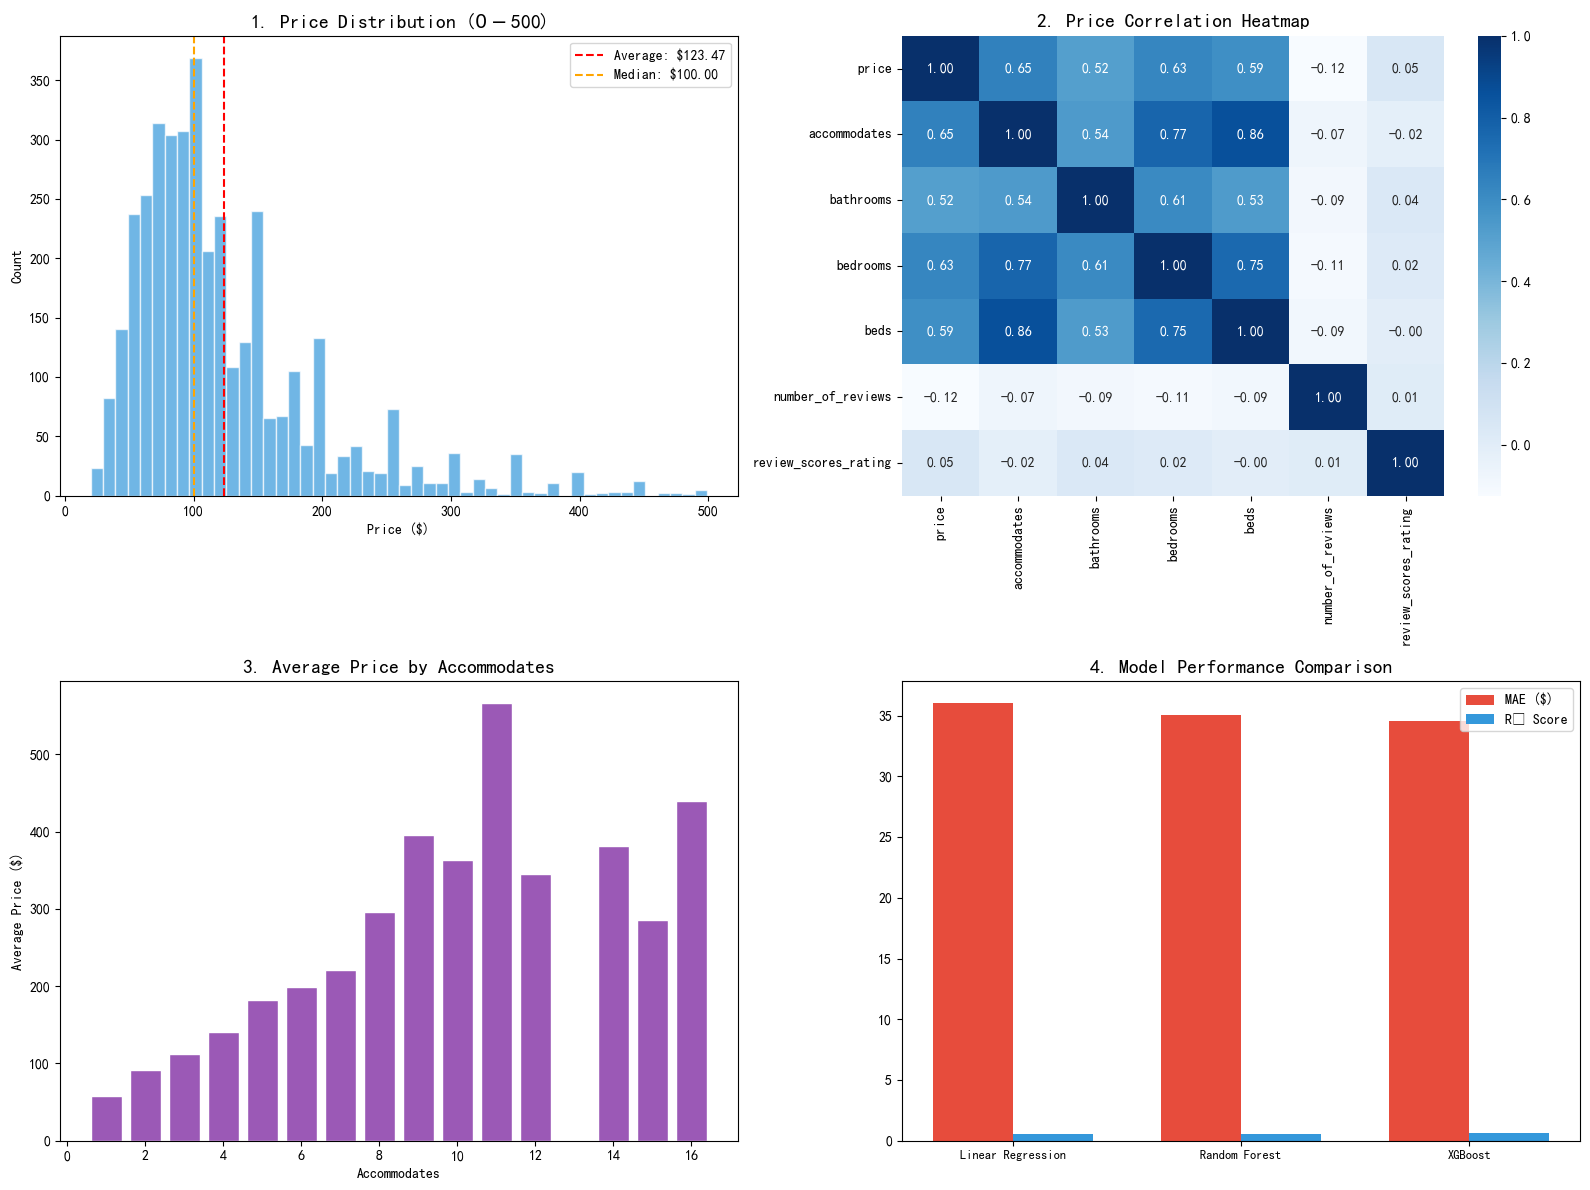

图片已保存


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))


price_filtered = df[(df['price'] < 500) & (df['price'] > 0)]['price']
axes[0, 0].hist(price_filtered, bins=50, color='#3498db', alpha=0.7, edgecolor='white')
axes[0, 0].axvline(price_filtered.mean(), color='red', linestyle='--', label=f'Average: ${price_filtered.mean():.2f}')
axes[0, 0].axvline(price_filtered.median(), color='orange', linestyle='--', label=f'Median: ${price_filtered.median():.2f}')
axes[0, 0].set_title('1. Price Distribution ($0-$500)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Price ($)')
axes[0, 0].set_ylabel('Count')
axes[0, 0].legend()


corr_cols = ['price', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'number_of_reviews', 'review_scores_rating']
corr_cols = [c for c in corr_cols if c in df.columns]
corr = df[corr_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues', ax=axes[0, 1])
axes[0, 1].set_title('2. Price Correlation Heatmap', fontsize=14, fontweight='bold')


if 'accommodates' in df.columns:
    acc_stats = df.groupby('accommodates')['price'].mean().reset_index()
    axes[1, 0].bar(acc_stats['accommodates'], acc_stats['price'], color='#9b59b6', edgecolor='white')
    axes[1, 0].set_title('3. Average Price by Accommodates', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Accommodates')
    axes[1, 0].set_ylabel('Average Price ($)')

# 模型性能对比
model_names = list(results.keys())
mae_vals = [results[m]['MAE'] for m in model_names]
r2_vals = [results[m]['R2'] for m in model_names]

x = np.arange(len(model_names))
w = 0.35
axes[1, 1].bar(x - w/2, mae_vals, w, label='MAE ($)', color='#e74c3c')
axes[1, 1].bar(x + w/2, r2_vals, w, label='R² Score', color='#3498db')
axes[1, 1].set_title('4. Model Performance Comparison', fontsize=14, fontweight='bold')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(model_names, fontsize=9)
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('airbnb_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


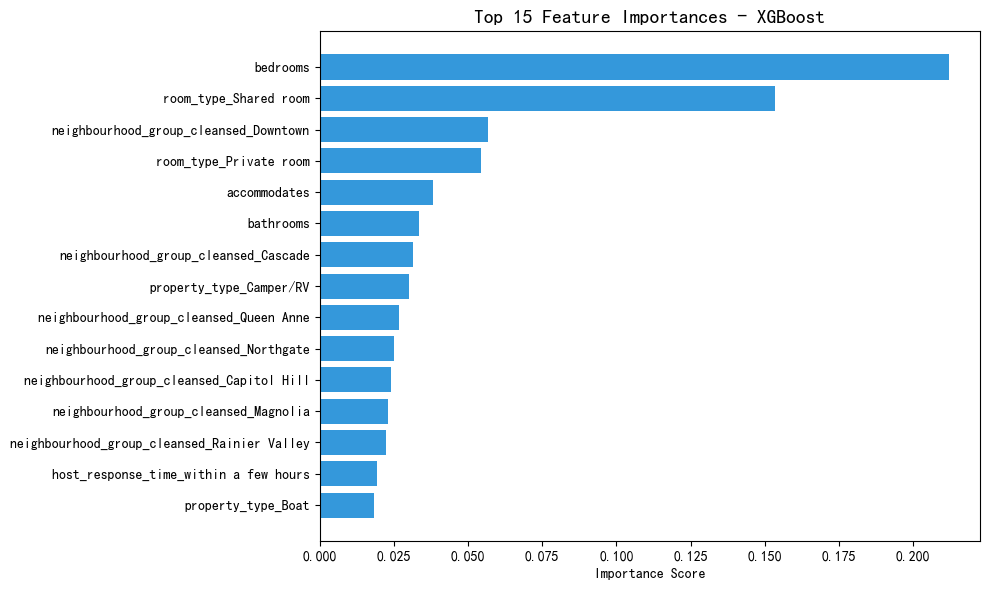


Top 15 影响价格的因素：
  bedrooms: 0.2120
  room_type_Shared room: 0.1534
  neighbourhood_group_cleansed_Downtown: 0.0569
  room_type_Private room: 0.0545
  accommodates: 0.0380
  bathrooms: 0.0336
  neighbourhood_group_cleansed_Cascade: 0.0316
  property_type_Camper/RV: 0.0301
  neighbourhood_group_cleansed_Queen Anne: 0.0267
  neighbourhood_group_cleansed_Northgate: 0.0250
  neighbourhood_group_cleansed_Capitol Hill: 0.0241
  neighbourhood_group_cleansed_Magnolia: 0.0231
  neighbourhood_group_cleansed_Rainier Valley: 0.0222
  host_response_time_within a few hours: 0.0193
  property_type_Boat: 0.0183


In [9]:
if 'XGBoost' in models:
    fi = pd.DataFrame({
        'feature': X.columns,
        'importance': models['XGBoost'].feature_importances_
    }).sort_values('importance', ascending=False).head(15)
    
    plt.figure(figsize=(10, 6))
    plt.barh(fi['feature'][::-1], fi['importance'][::-1], color='#3498db')
    plt.title('Top 15 Feature Importances - XGBoost', fontsize=14, fontweight='bold')
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\nTop 15 影响价格的因素：")
    for _, row in fi.iterrows():
        print(f"  {row['feature']}: {row['importance']:.4f}")